# FDverb offline demo

Copyright (C) 2026 Integrated Information Processing (IIP) group, ETH Zurich: https://iip.ethz.ch
Licensed under the GNU AGPL v3 or later. See LICENSE for details.

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import matplot2tikz
from tqdm import tqdm
from scipy.io import wavfile
import IPython.display as ipd
import os
from pathlib import Path

from fdverb.utils import load_fdverb_config
from fdverb.JuceRandom import JuceRandom

## Configuration


In [44]:
# load params from config

config_file = "default.yaml"
# config_file = "default.local.yaml"
# config_file = "dark-room.yaml"
# config_file = "live-room.yaml"
# config_file = "bell.yaml"
# config_file = "gated.yaml"
# config_file = "aura.yaml"
# config_file = "shifter.yaml"
# config_file = "drifter.yaml"
# config_file = "plot_dry-er-tail.yaml"
# config_file = "plot_envelope-grams.yaml"

# input_file = "audio_in/drum-fill.wav"
input_file = "audio_in/organ.wav"
# input_file = "audio_in/piano.wav"
# input_file = "audio_in/risset-drum.wav"

output_file = "out/out.wav"

write_audio_to_file = True
write_figures_to_file = False

In [45]:
repo_root = Path.cwd() / ".."
params = load_fdverb_config(str(repo_root / "presets" / config_file))

fig_out_dir = "fig_out/"
if write_figures_to_file:
    os.makedirs(fig_out_dir, exist_ok=True)

### global parameters
N = params["N"]  # transform block size
hop_size = N // 2

In [46]:
# convert dB levels to linear gains
def db_to_linear(db):
    if db <= -120.0:
        return 0.0
    return 10.0 ** (db / 20.0)


dry_gain = db_to_linear(params["DRYLEVEL"])
tail_gain = db_to_linear(params["TAILLEVEL"])
er_gain = db_to_linear(params["ERLEVEL"])

### Audio Input

In [47]:
# load and prepare audio data
fs, dry_sig = wavfile.read(input_file)

# normalization
if dry_sig.dtype == np.int16:
    dry_sig = dry_sig.astype(np.float32) / np.iinfo(np.int16).max
elif dry_sig.dtype == np.int32:
    dry_sig = dry_sig.astype(np.float32) / np.iinfo(np.int32).max
elif dry_sig.dtype == np.float32:
    pass  # already normalized
elif dry_sig.dtype == np.float64:
    dry_sig = dry_sig.astype(np.float32)

# convert mono to stereo if needed
if dry_sig.ndim == 1:
    dry_sig = np.stack([dry_sig, dry_sig], axis=1)

padding_before = N - hop_size  # for blockwise transform with window
min_padding_after = int(fs * (params["DECAY"] * 0.001 + 0.1))  # for reverb tail
padding_after = min_padding_after + (                               # extend padding_after to multiple of N
    -(dry_sig.shape[0] + padding_before + min_padding_after) % N
)
dry_sig = np.pad(dry_sig, ((padding_before, padding_after), (0, 0)), mode="constant")

print(f"dry_sig range: {dry_sig.min()} to {dry_sig.max()}")

dry_sig range: -0.2864467203617096 to 0.30433058738708496


/var/folders/np/v2db9r_n7tb84_3s9cwg6bfc0000gn/T/ipykernel_66939/589767349.py:2: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, dry_sig = wavfile.read(input_file)


## Early Reflections (ER)

Synthesize a sparse impulse response for the early reflections, then convolve with input to form ER output signal.

In [48]:
### ER parameters
er_num_taps = params["ERTAPS"]
er_predelay_samples = int(params["PREDELAY"] / 1000.0 * fs)
er_taildelay_samples = int(params["TAILDELAY"] / 1000.0 * fs)

assert er_taildelay_samples - er_predelay_samples > 0, "must be positive"

### synthesize ER taps
er_tap_samples = np.zeros(er_num_taps, dtype=np.int32)  # tap delay in samples
er_tap_amplitudes = np.zeros((er_num_taps, 2))

# seed random for reproducible pattern
rng_er = JuceRandom(seed=int(params["PREDELAY"]))
rng_er.next_int() # warm up

for tap in range(er_num_taps):
    # calculate tap position (biased toward early)
    if tap == 0:  # enforce first tap at pre-delay
        u = (
            er_predelay_samples / er_taildelay_samples
        ) ** 3  # ^3 compensates cubic root
    else:
        u = rng_er.uniform(
            (er_predelay_samples / er_taildelay_samples) ** 3, 1
        )  # restrict to [ pre/tail , 1 ]

    r = np.cbrt(u)  # sample from quadratic PDF
    er_tap_samples[tap] = int(r * er_taildelay_samples)

    # calculate amplitude with decay
    er_rt60 = params["DECAY"] * params.get(
        "ERDECAYSCALE", 0.16
    )  # RT60 for ERs relative to (global) RT60 for tail
    ampl = 10 ** (-3.0 * r * params["TAILDELAY"] / er_rt60)

    # calculate stereo pan
    width = params["WIDTH"]
    pan = 0.5 + width * (rng_er.random() - 0.5)
    pan = np.clip(pan, 0.0, 1.0)

    er_tap_amplitudes[tap, 0] = ampl * np.sqrt(1.0 - pan)
    er_tap_amplitudes[tap, 1] = ampl * np.sqrt(pan)

# sort taps by delay
sort_idx = np.argsort(er_tap_samples)
er_tap_samples = er_tap_samples[sort_idx]
er_tap_amplitudes = er_tap_amplitudes[sort_idx]

if params["ERPRESET"] == "boston_er":
    print("overwriting synthetic ER with Boston Symphony Hall")
    from fdverb import boston_er

    er_num_taps = boston_er.num_taps
    er_tap_samples = np.array(boston_er.times * fs, dtype=np.int32)
    er_tap_amplitudes = np.stack([boston_er.gains, boston_er.gains], axis=1)

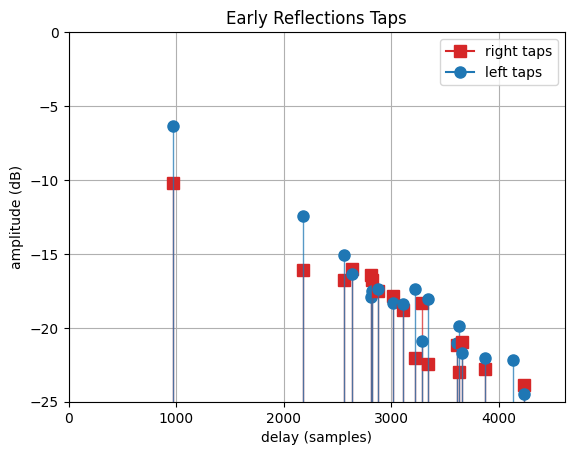

In [49]:
### visualize ER taps as vertical lines with marker, y axis in dB
ampl_db_left = 20 * np.log10(np.maximum(np.abs(er_tap_amplitudes[:, 0]), 1e-12))
ampl_db_right = 20 * np.log10(np.maximum(np.abs(er_tap_amplitudes[:, 1]), 1e-12))

for i in range(len(er_tap_samples)):
    # Right channel
    plt.vlines(
        er_tap_samples[i],
        -100,
        ampl_db_right[i],
        color="tab:red",
        linestyle="-",
        linewidth=1,
        alpha=0.75,
    )
    plt.plot(
        er_tap_samples[i],
        ampl_db_right[i],
        marker="s",
        color="tab:red",
        markersize=8,
        label="right taps" if i == 0 else "",
    )
    # Left channel
    plt.vlines(
        er_tap_samples[i],
        -100,
        ampl_db_left[i],
        color="tab:blue",
        linestyle="-",
        linewidth=1,
        alpha=0.75,
    )
    plt.plot(
        er_tap_samples[i],
        ampl_db_left[i],
        marker="o",
        color="tab:blue",
        markersize=8,
        label="left taps" if i == 0 else "",
    )


plt.legend()
plt.grid(True)
plt.xlabel("delay (samples)")
plt.ylabel("amplitude (dB)")
plt.title("Early Reflections Taps")
plt.xlim(0, er_taildelay_samples + 200)
plt.ylim(-25, 0)
plt.show()

In [50]:
### sparse convolution

er_sig = np.zeros_like(dry_sig)

for tap in range(er_num_taps):
    delay_samples = er_tap_samples[tap]
    if delay_samples < len(dry_sig):
        er_sig[delay_samples:, 0] += (
            dry_sig[:-delay_samples, 0] * er_tap_amplitudes[tap, 0]
        )
        er_sig[delay_samples:, 1] += (
            dry_sig[:-delay_samples, 1] * er_tap_amplitudes[tap, 1]
        )

## FDverb Reverb Tail

### Analysis

In [51]:
rng_tail = np.random.default_rng(seed=42)  # fix random seed

# mix reverberator input signal
s_sig = dry_sig + params["ER2TAIL"] * er_sig

# slice audio into overlapping blocks with 50% overlap
num_blocks = (len(s_sig) - N) // hop_size + 1
s_blocks = np.array(
    [s_sig[i * hop_size : i * hop_size + N, :] for i in range(num_blocks)]
)
# s_blocks shape: (num_blocks, N, 2)

# window
sine_window = np.sin(np.pi / N * (np.arange(N) + 0.5))
s_blocks = s_blocks * sine_window[np.newaxis, :, np.newaxis]

# freeze input (for foreverb mode)
if params["FOREVERB"] and params["FREEZEINPUT"]:
    s_blocks = np.zeros_like(s_blocks)

# spectral transform
s_blocks = np.transpose(s_blocks, (1, 0, 2))  # transpose to (N, num_blocks, 2)
s_spec = np.fft.rfft(s_blocks, axis=0, norm="ortho")
K = N // 2 + 1  # number nof bins

### Envelope Following

In [52]:
def decaytime_to_coef_exp(t60_ms, hop_size, fs):
    """Convert RT60 to a per-block exponential decay coefficient.

    Args:
      t60_ms: RT60 reverberation time in milliseconds.
      fs: Sample rate in Hz.
      hop_size: Hop size in samples.

    Returns:
      Per-block decay coefficient; 1.0 if t60_ms <= 0.
    """
    blocks_per_t60 = t60_ms * 0.001 * fs / hop_size
    return 1.0 - np.power(10.0, -3.0 / blocks_per_t60) if blocks_per_t60 > 0 else 1.0


def decaytime_to_coef_arith(t1_ms, hop_size, fs, slope_scale=2.0):
    """Convert decay time to a per-block arithmetic (linear) decay coefficient.

    Args:
      t1_ms: Time in milliseconds for an increase/decrease by 1.
      fs: Sample rate in Hz.
      hop_size: Hop size in samples.
      slope_scale: tweak slope to match percieved decay time (empirical parameter).

    Returns:
      Per-block amplitude decrement for linear decay over t1_ms milliseconds.
    """
    return slope_scale * hop_size / (fs * t1_ms * 0.001)

In [53]:
### compute envelope follower coefficients
if params["FOREVERB"]:  # TODO
    params["ENVMODE"] = "forever"

# attack coefficient (symbol alpha)
attack_coeff = decaytime_to_coef_exp(params["ATTACK"], hop_size, fs)

# tilt (frequency-dependent decay)
tilt = params["TILT"]
decay_time_ms = params["DECAY"]

upper_tilt_freq = 20000.0
lower_tilt_freq = 20.0
mid_tilt_freq = np.sqrt(upper_tilt_freq * lower_tilt_freq)
scale_factor = 2.0 / np.log10(upper_tilt_freq / lower_tilt_freq)

decay_coeffs = np.zeros(K)  # per-bin decay coefficients (symbol beta_k)

for i in range(K):
    if i == 0:
        tilt_factor = 1.0 + tilt
    else:
        bin_freq = i * fs / N
        tilt_factor = 1.0 - scale_factor * np.log10(bin_freq / mid_tilt_freq) * tilt

    tilt_factor = np.clip(tilt_factor, 0.0, 2.0)
    if params["ENVMODE"] == "exponential":
        decay_coeffs[i] = decaytime_to_coef_exp(
            decay_time_ms * tilt_factor, hop_size, fs
        )
    elif params["ENVMODE"] == "arithmetic":
        decay_coeffs[i] = decaytime_to_coef_arith(
            decay_time_ms * tilt_factor, hop_size, fs
        )

In [54]:
shift = params["SHIFT"]  # (symbol sigma)
drift = params["DRIFT"]  # (symbol delta)
color = float(params["COLOR"])  # (symbol gamma)

### compute envelopes
envelopes = np.zeros((K, num_blocks, 2), dtype=np.float32)

for frame in tqdm(range(num_blocks)):
    for ch in range(2):
        for bin in range(K):
            # shift: read magnitude from shifted bin
            src_bin = bin - shift
            if src_bin < 0 or src_bin >= K:
                env = 0.0
            else:
                env = np.abs(s_spec[src_bin, frame, ch])

            # rectify and apply power (color)
            env = np.abs(env) ** color

            # drift: read previous envelope from shifted bin
            env_bin = bin - drift
            if frame == 0 or env_bin < 0 or env_bin >= K:
                prev_env = 0.0
            else:
                prev_env = envelopes[env_bin, frame - 1, ch]

            # decay
            if params["ENVMODE"] == "exponential":
                if env >= prev_env:
                    envelopes[bin, frame, ch] = (
                        attack_coeff * env + (1.0 - attack_coeff) * prev_env
                    )
                else:
                    envelopes[bin, frame, ch] = (
                        decay_coeffs[bin] * env + (1.0 - decay_coeffs[bin]) * prev_env
                    )
            elif params["ENVMODE"] == "arithmetic":
                if env >= prev_env:
                    envelopes[bin, frame, ch] = min(prev_env + attack_coeff, env)
                else:
                    envelopes[bin, frame, ch] = max(
                        0.0, max(prev_env - decay_coeffs[bin], env)
                    )
            else:  # forever
                if env >= prev_env:
                    envelopes[bin, frame, ch] = env
                else:
                    envelopes[bin, frame, ch] = prev_env

# link envelopes (stereo coupling)
if params["LINK"]:
    envelopes[:, :, 0] = 0.5 * envelopes[:, :, 0] + 0.5 * envelopes[:, :, 1]
    envelopes[:, :, 1] = envelopes[:, :, 0]

100%|██████████| 65/65 [00:00<00:00, 73.67it/s]


#### Plot Time-Frequency Magnitude for Dry and Envelope Follower Output

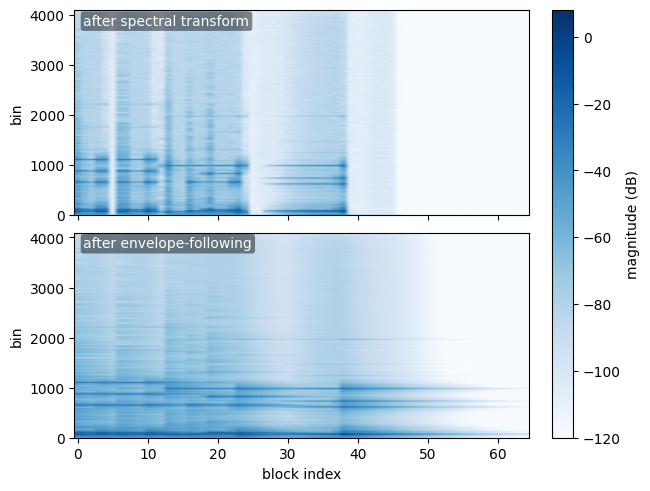

In [55]:
# visualize FFT data + envelopes
s_spec_plot = np.clip(np.mean(np.abs(s_spec), axis=2), 1e-6, None)
s_spec_plot_db = 20 * np.log10(s_spec_plot)
env_plot = np.clip(np.mean(envelopes, axis=2), 1e-6, None)  # (K, num_blocks)
env_plot_db = 20 * np.log10(env_plot)

# shared color scale
vmin = float(np.min([s_spec_plot_db.min(), env_plot_db.min()]))
vmax = float(np.max([s_spec_plot_db.max(), env_plot_db.max()]))


def panel_title(ax, label):
    ax.text(
        0.02,
        0.98,
        label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        color="white",
        bbox=dict(
            boxstyle="round,pad=0.2", facecolor="black", alpha=0.45, edgecolor="none"
        ),
    )


fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, constrained_layout=True)

colormap = "Blues"
im1 = ax1.imshow(
    s_spec_plot_db, aspect="auto", origin="lower", cmap=colormap, vmin=vmin, vmax=vmax
)
ax1.set_ylabel("bin")
panel_title(ax1, "after spectral transform")

im2 = ax2.imshow(
    env_plot_db, aspect="auto", origin="lower", cmap=colormap, vmin=vmin, vmax=vmax
)
ax2.set_xlabel("block index")
ax2.set_ylabel("bin")
panel_title(ax2, "after envelope-following")

fig.colorbar(im1, ax=[ax1, ax2], label="magnitude (dB)")
plt.show()

### Generate Noise and Apply Envelope

In [56]:
# brick EQ mask
low_cut_bin = int(params["LOWCUT"] * N / fs)
high_cut_bin = int(params["HIGHCUT"] * N / fs)

eq_mask = np.zeros(K)
eq_mask[low_cut_bin : high_cut_bin + 1] = 1.0

# generate random noise and apply mask
noise_spec = rng_tail.uniform(-1.0, 1.0, envelopes.shape)
noise_spec = noise_spec * eq_mask[:, np.newaxis, np.newaxis]  # apply in "bin" axis

# M/S stereo width: 0=mid only, 1=mid+side equally, 2=side only
# since noise is uncorrelated, we can directly interpret the L/R noise as M/S
width = params["WIDTH"]
mid_gain = 1.0 if width <= 1.0 else (2.0 - width)
side_gain = width if width <= 1.0 else 1.0
mid = noise_spec[..., 0]
side = noise_spec[..., 1]
noise_spec = np.stack(
    [mid_gain * mid + side_gain * side, mid_gain * mid - side_gain * side], axis=-1
)

# weight noise with envelopes
tail_spec = noise_spec * envelopes

### Synthesis

In [57]:
if params["DBG_TRANSFORMONLY"]:
    tail_spec = s_spec  # debug bypass mode

# inverse FFT
tail_blocks = np.fft.irfft(tail_spec, axis=0, norm="ortho")

# apply second sine window
tail_blocks = tail_blocks * sine_window[:, np.newaxis, np.newaxis]

# overlap-add
tail_sig = np.zeros((len(dry_sig), 2), dtype=np.float32)

for frame in range(num_blocks):
    start = frame * hop_size
    tail_sig[start : start + N, :] += tail_blocks[:, frame, :]

In [58]:
# check if tail-delay violates causality
if not params["DBG_IGNORECAUSALITY"]:
    assert (
        er_taildelay_samples >= N // 2
    ), "non-causailty detected: tail delay must be greater than half the block size"
elif er_taildelay_samples < N // 2:
    print("Warning: tail-delay violates causality!")
    print(f"er_taildelay_samples: {er_taildelay_samples}, N//2: {N//2}")

# delay tail_sig tail
taildelay_phy_samples = N + (
    er_taildelay_samples - N // 2
)  # N for causality, term in brackets for tail-delay
tail_sig = np.pad(
    tail_sig[:-taildelay_phy_samples, :], ((taildelay_phy_samples, 0), (0, 0))
)

## Combine Dry + ER + Tail

In [59]:
### remove initial padding
dry_sig = dry_sig[hop_size:]
er_sig = er_sig[hop_size:]
tail_sig = tail_sig[hop_size:]


### mix output

# mix dry, ER, and tail_sig tail
out_sig = dry_sig * dry_gain + er_sig * er_gain + tail_sig * tail_gain

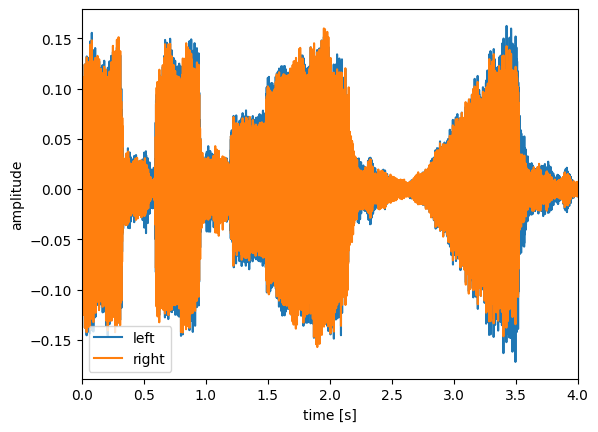

In [60]:
t = np.arange(len(out_sig)) / fs

plt.plot(t, out_sig[:, 0], label="left")
plt.plot(t, out_sig[:, 1], label="right")
plt.xlabel("time [s]")
plt.ylabel("amplitude")
plt.xlim((0, 4))
plt.legend()

### Write Output to File

In [61]:
if np.max(np.abs(out_sig)) > 1.0:
    print("Warning: Output contains values outside [-1, 1] and will be clipped.")
    print(f"peak magnitude: {np.max(np.abs(out_sig))}")
    out_sig = np.clip(out_sig, -1.0, 1.0)


# write to file
if write_audio_to_file:
    out_sig_i16 = (out_sig * 32767).astype(np.int16)
    output_dir = os.path.dirname(output_file) or "."
    os.makedirs(output_dir, exist_ok=True)
    wavfile.write(output_file, fs, out_sig_i16)


# play audio
ipd.Audio(out_sig.T, rate=fs, autoplay=True)

### Generate Plots for Demo Paper

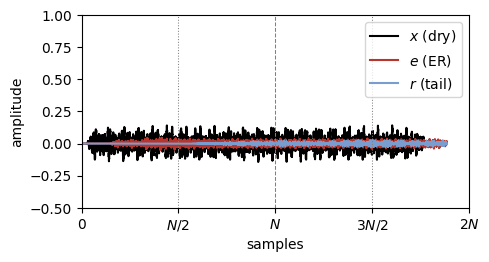

In [62]:
### dry + ER + tail
# to reproduce plot, set:
# config_file = "plot_dry-er-tail.yaml"
# input_file = "audio_in/risset-drum.wav"

t_max = 0.35  # seconds
x_max = int(t_max * fs)  # plot only x_max samples


plt.figure(figsize=(5, 2.5))
plt.plot(dry_sig[:x_max, 0] * dry_gain, color="#000000", label="$x$ (dry)")
plt.plot(er_sig[:x_max, 0] * er_gain, color="#B7352D", label="$e$ (ER)")
plt.plot(tail_sig[:x_max, 0] * tail_gain, color="#7A9DCF", label="$r$ (tail)")
plt.xlabel("samples")
plt.ylabel("amplitude")
plt.legend(loc="upper right")
plt.xlim(0.0, x_max)
plt.ylim(-0.5, 1.0)
plt.xticks(
    [0, N // 2, N, 3 * N // 2, 2 * N], [r"$0$", r"$N/2$", r"$N$", r"$3N/2$", r"$2N$"]
)

# add vertical lines at frame limits (overlap -> each frame spans two segments)
block_boundaries = np.arange(hop_size, x_max, hop_size)
for i, b in enumerate(block_boundaries):
    linestyle = "dotted" if i % 2 == 0 else "dashed"
    plt.axvline(b, color="gray", linestyle=linestyle, linewidth=0.75)

if write_figures_to_file:
    matplot2tikz.clean_figure()
    matplot2tikz.save(
        fig_out_dir + "dry-er-tail.tikz.tex",
        axis_width="8cm",
        axis_height="5cm",
        extra_axis_parameters=["scaled x ticks=false"],
    )

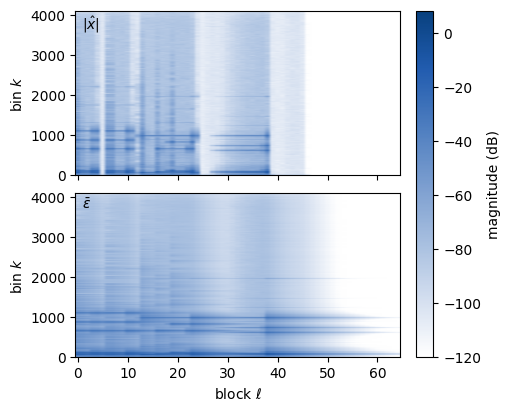

In [63]:
### envelope-follower time-frequency magnitude
# to reproduce plot, set:
# config_file = "plot_envelope-grams.yaml"
# input_file = "audio_in/organ.wav"

s_spec_plot = np.clip(np.mean(np.abs(s_spec), axis=2), 1e-6, None)
s_spec_plot_db = 20 * np.log10(s_spec_plot)
env_plot = np.clip(np.mean(envelopes, axis=2), 1e-6, None)  # (K, num_blocks)
env_plot_db = 20 * np.log10(env_plot)

# trim
x_max = 1400
s_spec_plot_db = s_spec_plot_db[:, :x_max]
env_plot_db = env_plot_db[:, :x_max]

# shared color scale
vmin = float(np.min([s_spec_plot_db.min(), env_plot_db.min()]))
vmax = float(np.max([s_spec_plot_db.max(), env_plot_db.max()]))


def panel_title(ax, label):
    ax.text(
        0.02,
        0.98,
        label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        # color='white',
        # bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.45, edgecolor='none'),
    )


# custom blue colormap (light 10% → dark 120%)
from matplotlib.colors import LinearSegmentedColormap

_eth_blue_stops = [
    (255, 255, 255),  #  0%
    (211, 222, 239),  # 20%
    (166, 190, 223),  # 40%
    (122, 157, 207),  # 60%
    (77, 125, 191),  # 80%
    (33, 92, 175),  # 100% RAL5005
    (8, 64, 126),  # 120%
]
_eth_blue_rgb = [(r / 255, g / 255, b / 255) for r, g, b in _eth_blue_stops]
colormap = LinearSegmentedColormap.from_list("eth_blue", _eth_blue_rgb)

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(5, 4), sharex=True, constrained_layout=True
)

im1 = ax1.imshow(
    s_spec_plot_db, aspect="auto", origin="lower", cmap=colormap, vmin=vmin, vmax=vmax
)
ax1.set_ylabel(r"bin $k$")
panel_title(ax1, r"$|\hat{x}|$")

im2 = ax2.imshow(
    env_plot_db, aspect="auto", origin="lower", cmap=colormap, vmin=vmin, vmax=vmax
)
ax2.set_xlabel(r"block $\ell$")
ax2.set_ylabel(r"bin $k$")
panel_title(ax2, r"$\bar{\varepsilon}$")

fig.colorbar(im1, ax=[ax1, ax2], label="magnitude (dB)")
plt.show()

if write_figures_to_file:
    n_bins, n_frames = s_spec_plot_db.shape

    # 1) bare raster panels
    plt.imsave(
        fig_out_dir + "envelope-grams-input.png",
        s_spec_plot_db,
        cmap=colormap,
        vmin=vmin,
        vmax=vmax,
        origin="lower",
    )
    plt.imsave(
        fig_out_dir + "envelope-grams-envelope.png",
        env_plot_db,
        cmap=colormap,
        vmin=vmin,
        vmax=vmax,
        origin="lower",
    )

    # 2) layout parameters
    panel_w, panel_h, vsep = 5.0, 2.5, 0.25  # cm
    cb_h = 2 * panel_h + vsep
    cb_yshift = panel_h + vsep

    # 3) sample colorbar
    stops = (colormap(np.linspace(0, 1, 24))[:, :3] * 255).round().astype(int)
    cmap_def = "  colormap={eth_blue}{\n%s\n  },\n" % (
        "\n".join("    rgb255=(%d,%d,%d)" % tuple(c) for c in stops)
    )

    # 4) write the self-contained tikz fragment (one \input, two PNGs)
    tex = r"""\begin{tikzpicture}
\begin{groupplot}[
    group style={group size=1 by 2, vertical sep=%(vsep).3gcm,
                 x descriptions at=edge bottom},
    width=%(w).3gcm, height=%(h).3gcm,
    scale only axis, enlargelimits=false, axis on top,
%(cmap)s    point meta min=%(vmin).4f, point meta max=%(vmax).4f,
]
\nextgroupplot[ylabel={bin $k$}]
\addplot graphics [xmin=0, xmax=%(nf)d, ymin=0, ymax=%(nb)d] {envelope-grams-input.png};
\node[anchor=north west] at (rel axis cs:0.02,0.98) {$|\hat{x}|$};
\nextgroupplot[xlabel={block $\ell$}, ylabel={bin $k$},
    colorbar,
    colorbar style={ylabel={magnitude [dB]}, height=%(cbh).3gcm, yshift=%(cbs).3gcm}]
\addplot graphics [xmin=0, xmax=%(nf)d, ymin=0, ymax=%(nb)d] {envelope-grams-envelope.png};
\node[anchor=north west] at (rel axis cs:0.02,0.98) {$\bar{\varepsilon}$};
\end{groupplot}
\end{tikzpicture}
""" % dict(
        vsep=vsep,
        w=panel_w,
        h=panel_h,
        cmap=cmap_def,
        vmin=vmin,
        vmax=vmax,
        nf=n_frames,
        nb=n_bins,
        cbh=cb_h,
        cbs=cb_yshift,
    )

    with open(fig_out_dir + "envelope-grams.tikz.tex", "w") as f:
        f.write(tex)